# Step 2 — Ring-geometry inference with **dynesty** (nested sampling)

**Goal.** Given the transit observables from step 1, infer the posterior over ring geometry:
does a ring system exist that reproduces this planet's measured transit, and if so, what
does it look like?

## The forward model

A deterministic, purely geometric map from a ring configuration to transit observables. Its
three *external* inputs are the orbital period $P$, the impact parameter $b$, and the star's
true density $\rho_{\star,\rm true}$; its ring parameters are
$\boldsymbol\theta = (p,\ f_i,\ f_e,\ i_R,\ \theta_R,\ \tau)$.

**Why parameterise by $\rho_{\star,\rm true}$ instead of $M_\star$ and $R_\star$?** Because
every spatial scale in a transit is expressed in units of the stellar radius, so the absolute
$R_\star$ never enters — and using the density directly avoids requiring prior knowledge of the
host's mass and radius for the analysis itself. The scaled semimajor axis follows from Kepler's
third law,

$$\left(\frac{a}{R_\star}\right)_{\rm geo} =
  \left(\frac{G\,\rho_{\star,\rm true}}{3\pi}P^{2}\right)^{1/3},$$

and, for a circular orbit, $\cos i_{\rm orb} = b / (a/R_\star)_{\rm geo}$.

**Ring geometry.** A geometrically thin annulus from $f_i\,p$ to $f_e\,p$ (with
$p \equiv R_p/R_\star$), projected on the sky as an ellipse of semi-major axis $A = f_e p$ and
semi-minor axis $B = A\cos i_R$. Its opacity enters through a blocking factor

$$\beta = 1 - \exp\!\left(-\tau/\cos i_R\right),$$

which folds both blocking and absorption into the effective occulting area.

**The analytic contact-point formula is what makes this tractable.** The ring's contact
positions with the stellar limb come from a closed-form intersection of the limb with the
rotated projected ellipse. Being fully analytical, it can be evaluated inside a nested-sampling
loop without prohibitive cost — a numerically integrated model could not be. Final contacts are
$x_i = \min[x_{p,i},\ x_{R,i}]$, and the durations follow:

$$T_{14}^{\rm geo} = \frac{P}{2\pi}\arcsin\!\left[\frac{x_4 - x_1}
  {(a/R_\star)_{\rm geo}\sin i_{\rm orb}}\right], \qquad
  T_{23}^{\rm geo} = \frac{P}{2\pi}\arcsin\!\left[\frac{x_3 - x_2}
  {(a/R_\star)_{\rm geo}\sin i_{\rm orb}}\right].$$

## The likelihood

The step-1 posterior gives $N$ joint samples $\{\mathbf{y}_m\}$ of the observables. They are
smoothed into a multivariate Gaussian KDE,

$$\widehat{p}(\mathbf{y}) = \frac{1}{N}\sum_{m=1}^{N}
  \mathcal{N}\!\left(\mathbf{y}\,\middle|\,\mathbf{y}_m,\ \mathbf{H}\right),
  \qquad \mathbf{H} = h^{2}\boldsymbol\Sigma,$$

and the likelihood is that density evaluated at the model prediction:

$$\mathcal{L}(\boldsymbol\theta) \propto
  \widehat{p}\!\left(\mathbf{y} = \mathbf{y}(\boldsymbol\theta)\right).$$

This propagates the **correlated** uncertainties among the observables without collapsing them
to independent point estimates or assuming a parametric likelihood shape — which matters,
because the observables are strongly covariant by construction (they all derive from the same
photometric fit).

## Which observables to include

Configurable in `KDE_CONFIG["observables"]`, any subset of:

| Key | Observable |
|---|---|
| `delta` | transit depth $\delta$ |
| `T14` | total duration $T_{14}$ [h] |
| `T23` | flat-bottom duration $T_{23}$ [h] |
| `rho_obs` | transit-inferred stellar density [g cm$^{-3}$] |
| `b_obs` | transit-inferred impact parameter |

Using several is essential rather than cosmetic: distinct ring configurations can produce
nearly identical depths while differing in contact times or in the density anomaly, and some
configurations produce **no** density bias at all (the $PR = 0$ locus). Multiple observables
are what break those degeneracies.

## Sampler

`dynesty` static nested sampling, which returns posterior samples *and* the Bayesian evidence
$\ln Z$, and copes well with the irregular likelihood geometry a KDE constraint induces.


## 0. Environment


In [8]:
# ── Bootstrap: make the sibling packages importable without installation ────
# The pipeline uses three packages that live in the repository, uninstalled:
#   exorings, geotrans   (repo root)      photoring   (pipeline/)
# We locate the repo root and pipeline/ robustly from the current working dir
# (Jupyter / nbconvert / papermill all run notebooks from pipeline/).
import sys, pathlib
_HERE   = pathlib.Path.cwd().resolve()
_cands  = [_HERE, *_HERE.parents]
_NB_DIR = next((c for c in _cands if (c / "photoring").is_dir()), _HERE)
_REPO   = next((c for c in _cands if (c / "exorings").is_dir()), _NB_DIR.parent)
for _p in (str(_REPO), str(_NB_DIR)):
    if _p not in sys.path:
        sys.path.insert(0, _p)
print("repo root :", _REPO)
print("pipeline  :", _NB_DIR)

repo root : /home/numpaque/AppPR
pipeline  : /home/numpaque/AppPR/pipeline


In [9]:
import numpy as np
import warnings, os, time
warnings.filterwarnings("ignore")
# Limit BLAS threads before heavy numerics (pool workers each add threads).
for _v in ["OMP_NUM_THREADS","MKL_NUM_THREADS","OPENBLAS_NUM_THREADS",
           "VECLIB_MAXIMUM_THREADS","NUMEXPR_NUM_THREADS"]:
    os.environ.setdefault(_v, "2")

import photoring as pr
import photoring.plotting as plot
plot.apply_style()

import dynesty
from dynesty import plotting as dyplot
print("dynesty", dynesty.__version__)

dynesty 3.0.0


## 1. USER CONFIGURATION  ← edit here (papermill-injected)

This cell carries the `parameters` tag, so `run_sweep.py` can override any of it to sweep
configurations. Four groups:

- **`CASE` / `PLANET`** — which case directory and which planet.
- **`PLANET_PARAMS`** — per-planet external constraints: the impact-parameter prior centre and
  width, and the reference radius ratio with its lower prior bound as a fraction.
- **`KDE_CONFIG`** — which observables enter the likelihood, how many posterior samples train
  the KDE, and the training seed.
- **`NS_CONFIG`** — nested-sampling settings.
- **`MODEL_CONFIG`** — which parameters are free and which are fixed (see §2).

### Priors, and the reasoning behind each

| Parameter | Prior | Why |
|---|---|---|
| $f_e$ | $\mathcal{U}(1,\ f_{e,\max})$ | $f_{e,\max}=10$ from the prograde stability limit near $0.5\,R_{\rm Hill}$ |
| $f_i$ | fixed at 1 | the photometry cannot resolve structure interior to the ring's outer edge |
| $i_R$ | $p(i_R)\propto\sin i_R$ | isotropic orientations; note this already favours edge-on |
| $\theta_R$ | $\mathcal{U}(0^\circ,90^\circ)$ | no preferred azimuth |
| $p$ | $\mathcal{U}(p_{\min},\ p_{\rm obs})$ | $p_{\min}$ from a maximum, Earth-like bulk density; the upper bound is the ringless fit |
| $\tau$ | $p(\tau)\propto 1/\tau$ on $[0.1,10]$ | log-uniform over an unknown scale; fixed to 1 in baseline runs, comparable to Saturn's main rings, to avoid a parameter partly degenerate with ring size and orientation |
| $\rho_{\star,\rm true}$ | empirical KDE of an independent (isochrone) posterior | an external constraint, not something the transit should revise |
| $b$ | truncated normal on $[0,1]$ | centred on the published ringless fit; bounded because $b$ is physically confined |

Letting $p$ float matters physically: part of the observed depth may be produced by the ring,
which implies a *smaller* planet. Fixing $p = p_{\min}$ instead explores the opposite limit —
maximum ring extent — and is best read as a bounding case rather than a favoured solution.


In [10]:
# All entries must be plain literals (papermill injects scalars/lists/dicts here).
CASE   = "kepler_51"
PLANET = "d"            # papermill overrides -> 'b' or 'd'

# Planet-specific priors (Masuda 2024). Resolved into MODEL_CONFIG below.
PLANET_PARAMS = {
    "d": dict(B_FIXED=0.0030, B_SIGMA=2 * 0.0950, p_mean_ref=0.09857, p_prior_lo=0.20353),
    "b": dict(B_FIXED=0.0740, B_SIGMA=2 * 0.0720, p_mean_ref=0.07225, p_prior_lo=0.27767),
}

KDE_CONFIG = {"observables": ["delta", "rho_obs", "T14"], 
              "N_KDE": 5000, 
              "seed_kde": 123
              }

NS_CONFIG = {"nlive": 1200, 
             "sample": "rslice", 
             "dlogz": 0.01, 
             "bound": "multi",
             "seed": 2026, 
             "use_pool": True, 
             "n_procs": int(os.cpu_count()/2)
             }

# Defaults reproduce the manuscript's adopted configuration: the *fully free*
# model, which is the only one in the retrieval suite that reproduces the full set
# of transit observables (see section 2). Flip any flag to False to explore the
# simpler variants; run_sweep.py sweeps them.
MODEL_CONFIG = {
    "B_FREE": True, 
    "B_FIXED": PLANET_PARAMS[PLANET]["B_FIXED"],
    "B_SIGMA": PLANET_PARAMS[PLANET]["B_SIGMA"],
    "RHO_TRUE_FREE": True, 
    "RHO_TRUE_FIXED": None,
    "FI_FIXED": 1.0, 
    "FE_MAX": 10.0,
    "ALPHA_FREE": True, 
    "ALPHA_FIXED": 0.36787944117144233,   # exp(-1), equiv. tau=1
    "ALPHA_PRIOR_LO": 0.0, 
    "ALPHA_PRIOR_HI": 1.0,
    "P_FREE": True, 
    "p_mean_ref": PLANET_PARAMS[PLANET]["p_mean_ref"],
    "p_prior_lo": PLANET_PARAMS[PLANET]["p_prior_lo"], 
    "p_prior_hi": 1.0,
    "FORWARD_MODEL": "exorings",   # "exorings" (closed-form) or "geotrans" (numeric)
}

## 2. Build the model (data + KDE likelihood + priors)

`PhotoRingModel` assembles the forward model, the KDE likelihood and the prior transform, and
resolves which parameters are free.

### Free vs fixed, and why it changes the answer

$b$ and $\rho_{\star,\rm true}$ are not ring properties — they set the transit chord and the
orbital scale — but they carry observational uncertainty. Three treatments are possible: fix
them to their central values, sample them under informative priors, or marginalise over them
inside the likelihood via a pseudo-marginal Monte Carlo average

$$\mathcal{L}(\boldsymbol\theta) \approx \frac{1}{M}\sum_{j=1}^{M}
  \widehat{p}\!\left(\mathbf{y} = \mathbf{y}\big(\boldsymbol\theta,\
  \rho_{\star,\rm true}^{(j)},\ b^{(j)}\big)\right),$$

with the draws taken from their adopted priors. The last is the formally correct Bayesian
treatment when these are *external* constraints that the transit data should not revise.

This choice is consequential, not a detail: fixing $\rho_{\star,\rm true}$ forces the ring
geometry to absorb all the tension and the model then fails to reproduce the transit durations.
Sampling both jointly is what recovers a geometry consistent with the full observable set.

The dimensionality is $4 + $ `TAU_FREE` $+$ `RHO_TRUE_FREE` $+$ `B_FREE` (4–7D), and the
parameter vector order is always
`[fe, ir, theta, p, (tau), (rho_true), (b)]`.


In [11]:
paths = pr.CasePaths(CASE)
FORWARD_MODEL = str(MODEL_CONFIG.get("FORWARD_MODEL", "exorings")).lower()
paths.ensure_outputs(FORWARD_MODEL)

# Load the case's derived observables, rho_true samples and inverse-CDF grid.
data  = pr.load_case_data(paths, PLANET)
model = pr.PhotoRingModel(
    data["ttv"], data["rho_true_gcc_samples"], MODEL_CONFIG, KDE_CONFIG,
    rho_grid=data["rho_grid"], rho_cdf=data["rho_cdf"], p_fixed=data["P_fixed"],
)
print(f"Planet {PLANET}: {len(data['ttv']['delta'])} TTV samples | P_fixed={data['P_fixed']:.6f} d")
print(f"NDIM={model.NDIM}  params={model.PARAM_NAMES}")

Planet d: 39002 TTV samples | P_fixed=130.178030 d
NDIM=7  params=['fe', 'ir', 'theta', 'p', 'tau', 'rho_true', 'b']


In [12]:
# Reproducible run tag encoding the full configuration.
_kt = "-".join(model.observables)
RUN_TAG = (f"{CASE}_{PLANET}_NS_{FORWARD_MODEL}_kde_{_kt}"
           f"_nlive{NS_CONFIG['nlive']}_dlogz{NS_CONFIG['dlogz']}"
           f"_NKDE{KDE_CONFIG['N_KDE']}_seed{NS_CONFIG['seed']}{model.free_tag()}")
print("RUN_TAG:", RUN_TAG)

RUN_TAG: kepler_51_d_NS_exorings_kde_delta-rho_obs-T14_nlive1200_dlogz0.01_NKDE5000_seed2026_rhoFREE_bFREE_tauFREE_pFREE


## 3. KDE self-consistency check

Before sampling: does the KDE actually represent the posterior it was trained on? This draws
fresh samples from the fitted KDE and overlays them on the training histograms. A visible
mismatch here means the likelihood target is wrong, and everything downstream would inherit
that — a bandwidth or a training-sample problem is far cheaper to catch now than after a run.


  Saved -> /home/numpaque/AppPR/pipeline/kepler_51/figures/kde_ppc/kepler_51_d_NS_exorings_kde_delta-rho_obs-T14_nlive1200_dlogz0.01_NKDE5000_seed2026_rhoFREE_bFREE_tauFREE_pFREE_kde_ppc.png


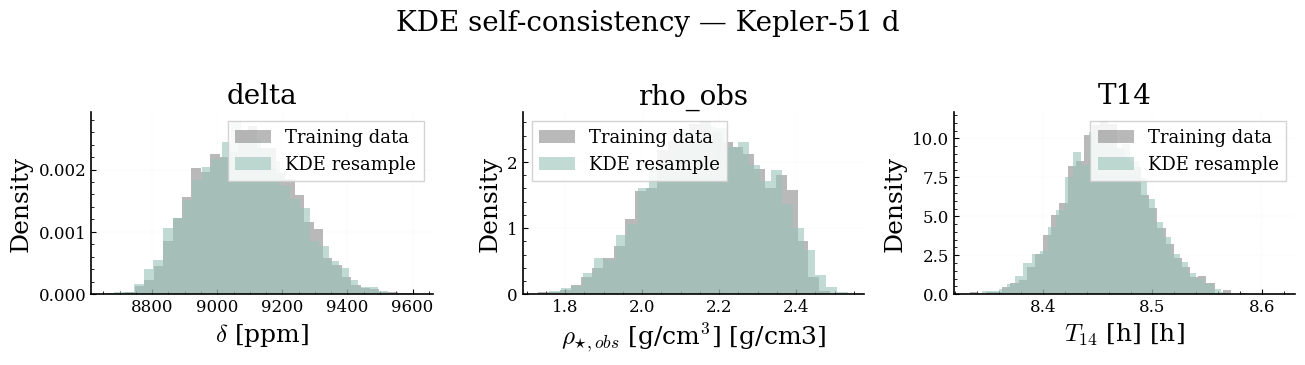

In [13]:
plot.plot_kde_ppc(model, planet=PLANET, paths=paths, run_tag=RUN_TAG); import matplotlib.pyplot as plt; plt.show()

## 4. Nested sampling

Runs the sampler. Nested sampling integrates the likelihood over the prior shell by shell, so
alongside posterior samples it returns the **Bayesian evidence** $\ln Z$ — which is what allows
different configurations to be compared, rather than merely each being fitted.

The stopping criterion is the remaining evidence estimate, `dlogz`.


In [14]:
import multiprocessing as mp
try:    _ctx = mp.get_context("fork")
except ValueError: _ctx = mp

result = pr.run_dynesty(model, NS_CONFIG, ctx=_ctx)
print(f"\nlnZ = {result['logz']:.3f} +/- {result['logz_err']:.3f}"
      f"  | runtime {result['runtime_s']:.1f}s | N={len(result['chain'])}")

13993it [13:29, 17.29it/s, +1200 | bound: 81 | nc: 1 | ncall: 872419 | eff(%):  1.744 | loglstar:   -inf < 12.857 <    inf | logz:  2.109 +/-    nan | dlogz:  0.000 >  0.010]


lnZ = 2.109 +/- 0.091  | runtime 809.5s | N=15193


## 5. Posterior summary

Median and 68% credible interval per parameter. Worth checking against the priors in §1: a
marginal that reproduces its prior shape means the data constrained that parameter *not at all*,
which is itself a result — and for $i_R$, whose prior $\propto\sin i_R$ already favours edge-on
orientations, the informative quantity is precisely the **departure** from the prior shape.


In [15]:
for name, lbl in zip(model.PARAM_NAMES, model.PARAM_LABELS):
    s = result["stats"][name]; m = s["median"]
    print(f"  {name:>10}: {m:.5f}  [-{m-s['p16']:.5f}, +{s['p84']-m:.5f}]")

          fe: 1.62444  [-0.46445, +2.30441]
          ir: 70.26002  [-18.11237, +10.67622]
       theta: 66.04285  [-18.60437, +12.63792]
           p: 0.08414  [-0.03327, +0.01014]
         tau: 1.67295  [-1.32486, +4.06416]
    rho_true: 2.06231  [-0.13047, +0.17783]
           b: 0.30884  [-0.11655, +0.06306]


## 6. Posterior predictive check (all observables)

Posterior samples are pushed back through the forward model and the predicted distribution of
each observable is compared against the TTV-derived one, with three statistics: the
1-Wasserstein distance $W_1$ (mean absolute displacement between the empirical distributions),
the Kolmogorov–Smirnov $p$-value $p_{\rm KS}$ (null: same parent distribution), and an energy
distance $E$ (squared discrepancy).

**All five observables are checked, including those left out of the likelihood.** Fitting an
observable does not guarantee the others follow, so the excluded ones are a genuine
out-of-sample test of the inferred geometry. Panel titles mark which is which.


  Saved -> /home/numpaque/AppPR/pipeline/kepler_51/figures/ppc/kepler_51_d_NS_exorings_kde_delta-rho_obs-T14_nlive1200_dlogz0.01_NKDE5000_seed2026_rhoFREE_bFREE_tauFREE_pFREE_ppc.png


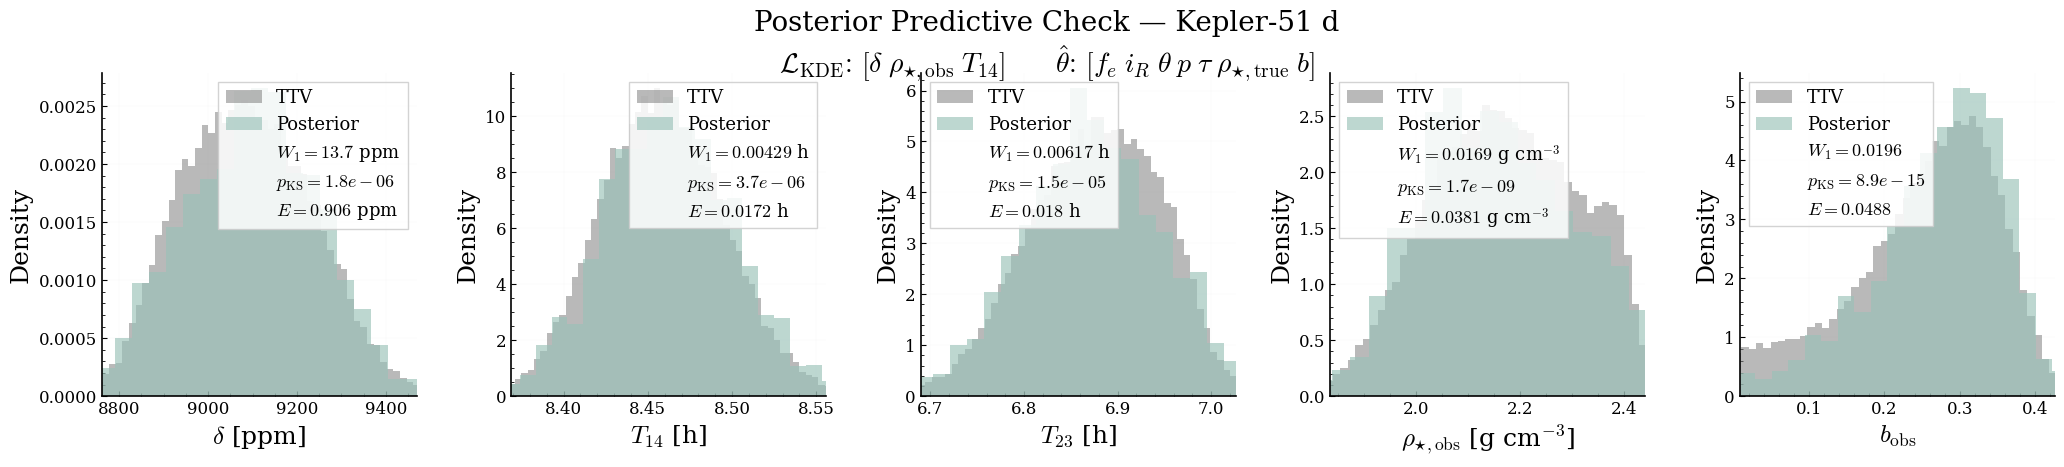

In [16]:
import matplotlib.pyplot as plt
ppc = pr.compute_ppc(model, result["chain"])
run = pr.make_run(model, result, RUN_TAG, PLANET, ppc=ppc)
plot.plot_ppc(run, data["ttv"], paths=paths); plt.show()

## 7. dynesty native diagnostics (run / trace plots)

Sampler-health checks, not science: the run plot shows evidence and likelihood accumulating
across nested-sampling iterations, and the trace plot shows where in each parameter the live
points went as the shells contracted. Together they reveal a run that stopped too early or that
never explored part of the prior.

These need the *live* result object; a run reloaded from `.npz` only carries a complete one if
the full sampling history was persisted (§9).


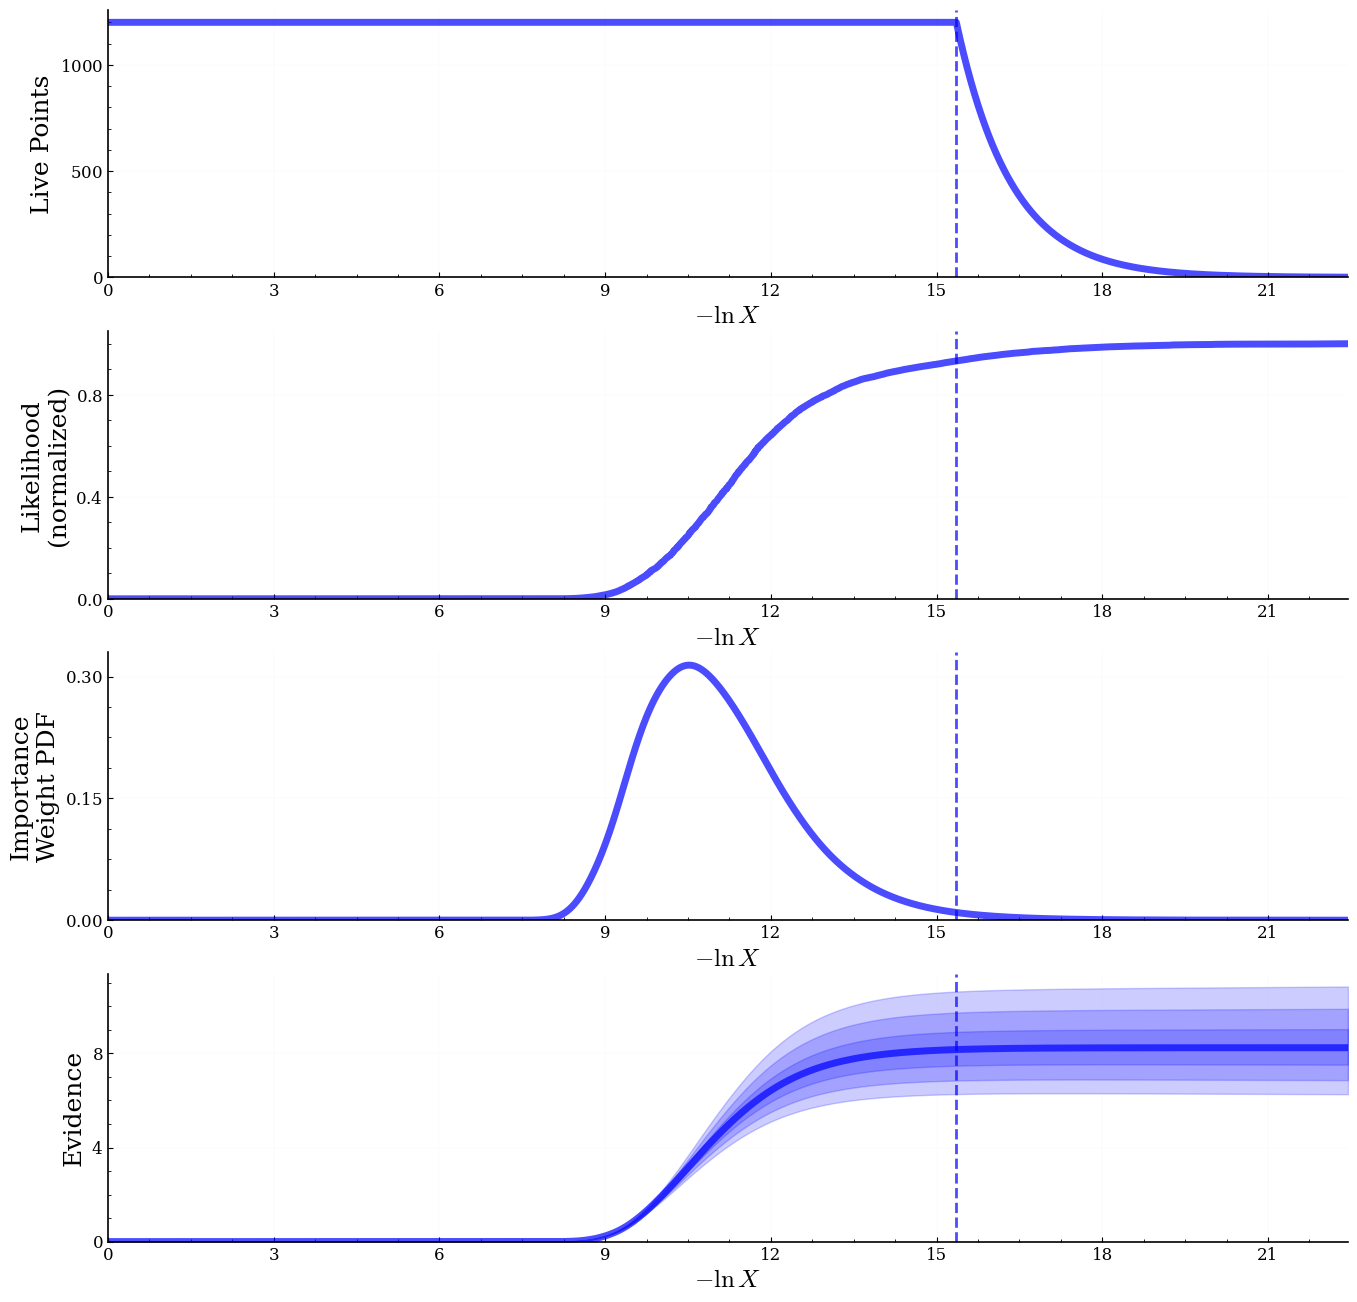

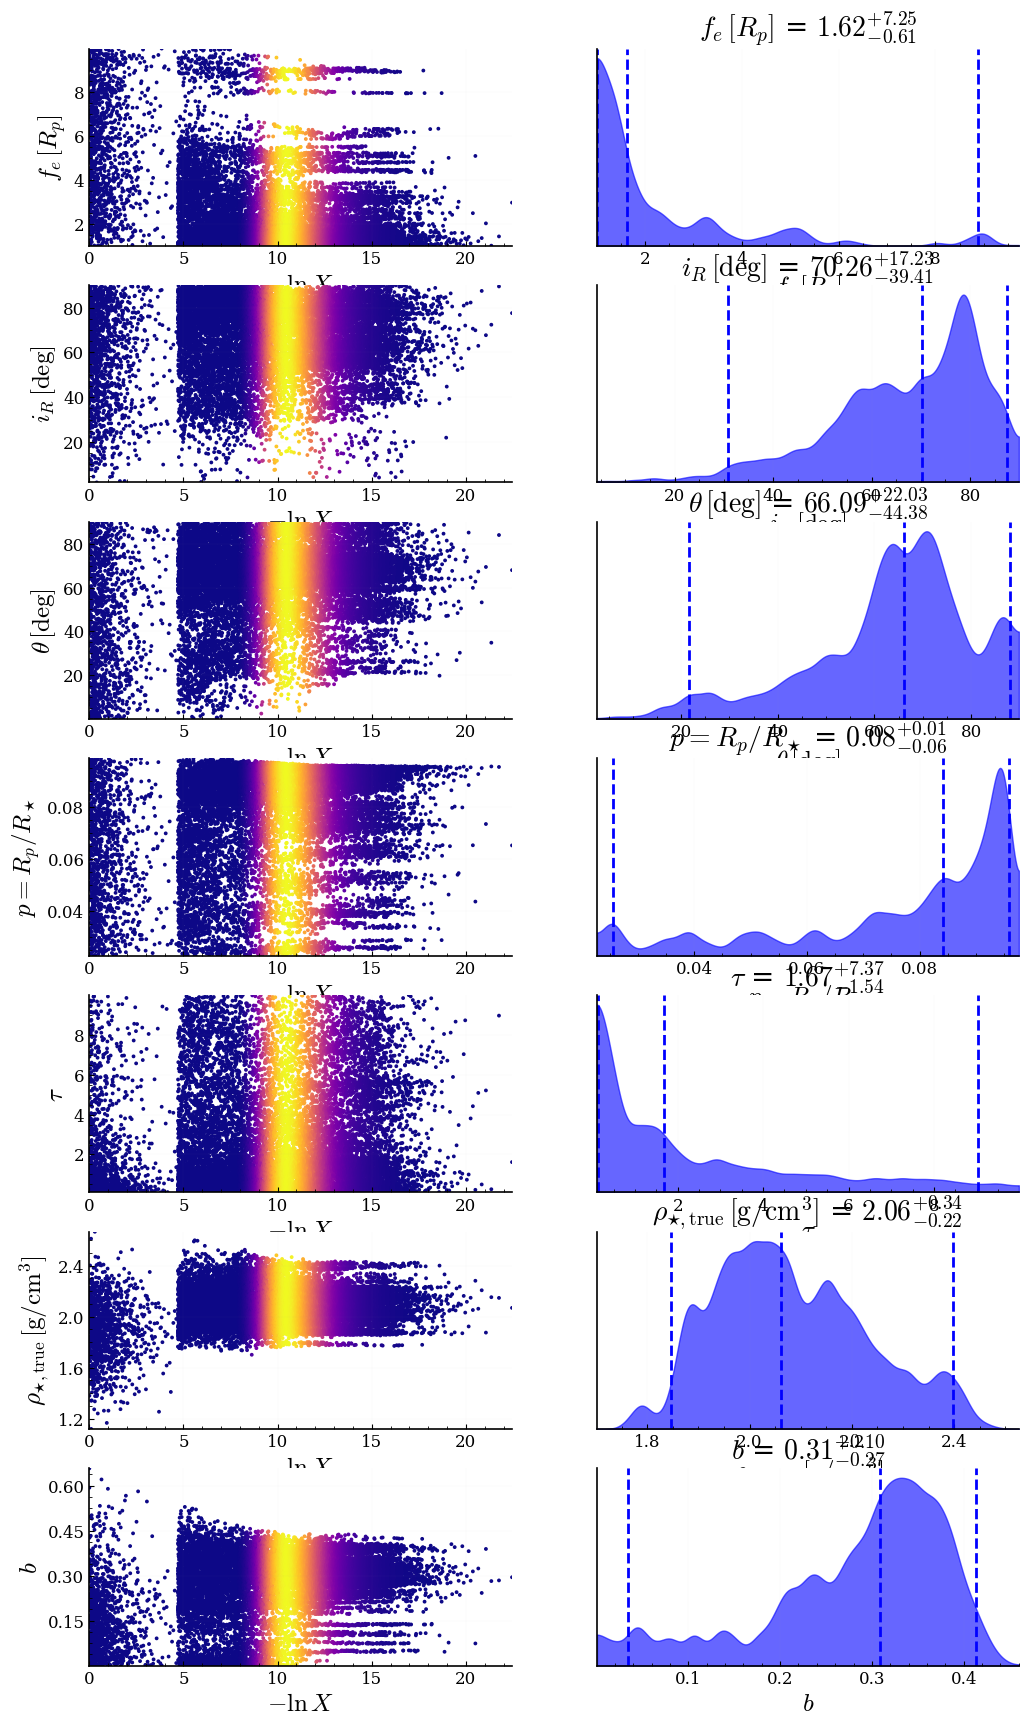

In [17]:
import matplotlib.pyplot as plt
dres = result["dres"]
fig_run, _ = dyplot.runplot(dres, lnz_error=True)
fig_run.savefig(paths.figures_dir("trace") / f"{RUN_TAG}_runplot.png", dpi=plot.STYLE["fig_dpi"]); plt.show()
fig_tr, _ = dyplot.traceplot(dres, labels=model.PARAM_LABELS, show_titles=True, trace_cmap="plasma")
fig_tr.savefig(paths.figures_dir("trace") / f"{RUN_TAG}_traceplot.png", dpi=plot.STYLE["fig_dpi"]); plt.show()

## 8. Marginals and corner (publication style)

The 1-D marginals with their priors overlaid, and the joint posterior as a corner plot.

The corner is drawn by `dynesty` from the **weighted** nested-sampling output — the posterior
the sampler actually produced. Watch for the parameter pairs that trade off against each other:
the $f_e$–$p$ anti-correlation in particular is intrinsic, since the effective occulting area
$A_{\rm eff} = \pi R_p^2 + A_{\rm ring}$ leaves the transit depth unchanged along any curve
that preserves it.


  Saved -> /home/numpaque/AppPR/pipeline/kepler_51/figures/marginal/kepler_51_d_NS_exorings_kde_delta-rho_obs-T14_nlive1200_dlogz0.01_NKDE5000_seed2026_rhoFREE_bFREE_tauFREE_pFREE_marginals.png


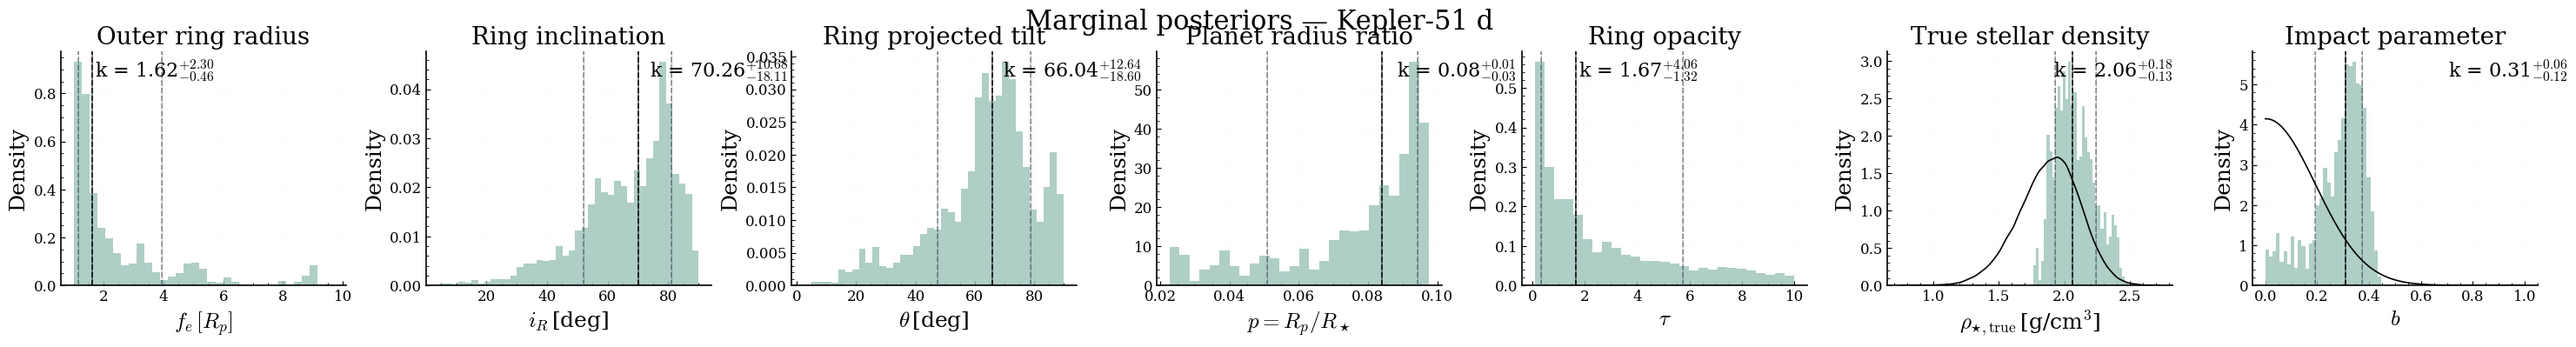

  Saved -> /home/numpaque/AppPR/pipeline/kepler_51/figures/corner/kepler_51_d_NS_exorings_kde_delta-rho_obs-T14_nlive1200_dlogz0.01_NKDE5000_seed2026_rhoFREE_bFREE_tauFREE_pFREE_corner.png


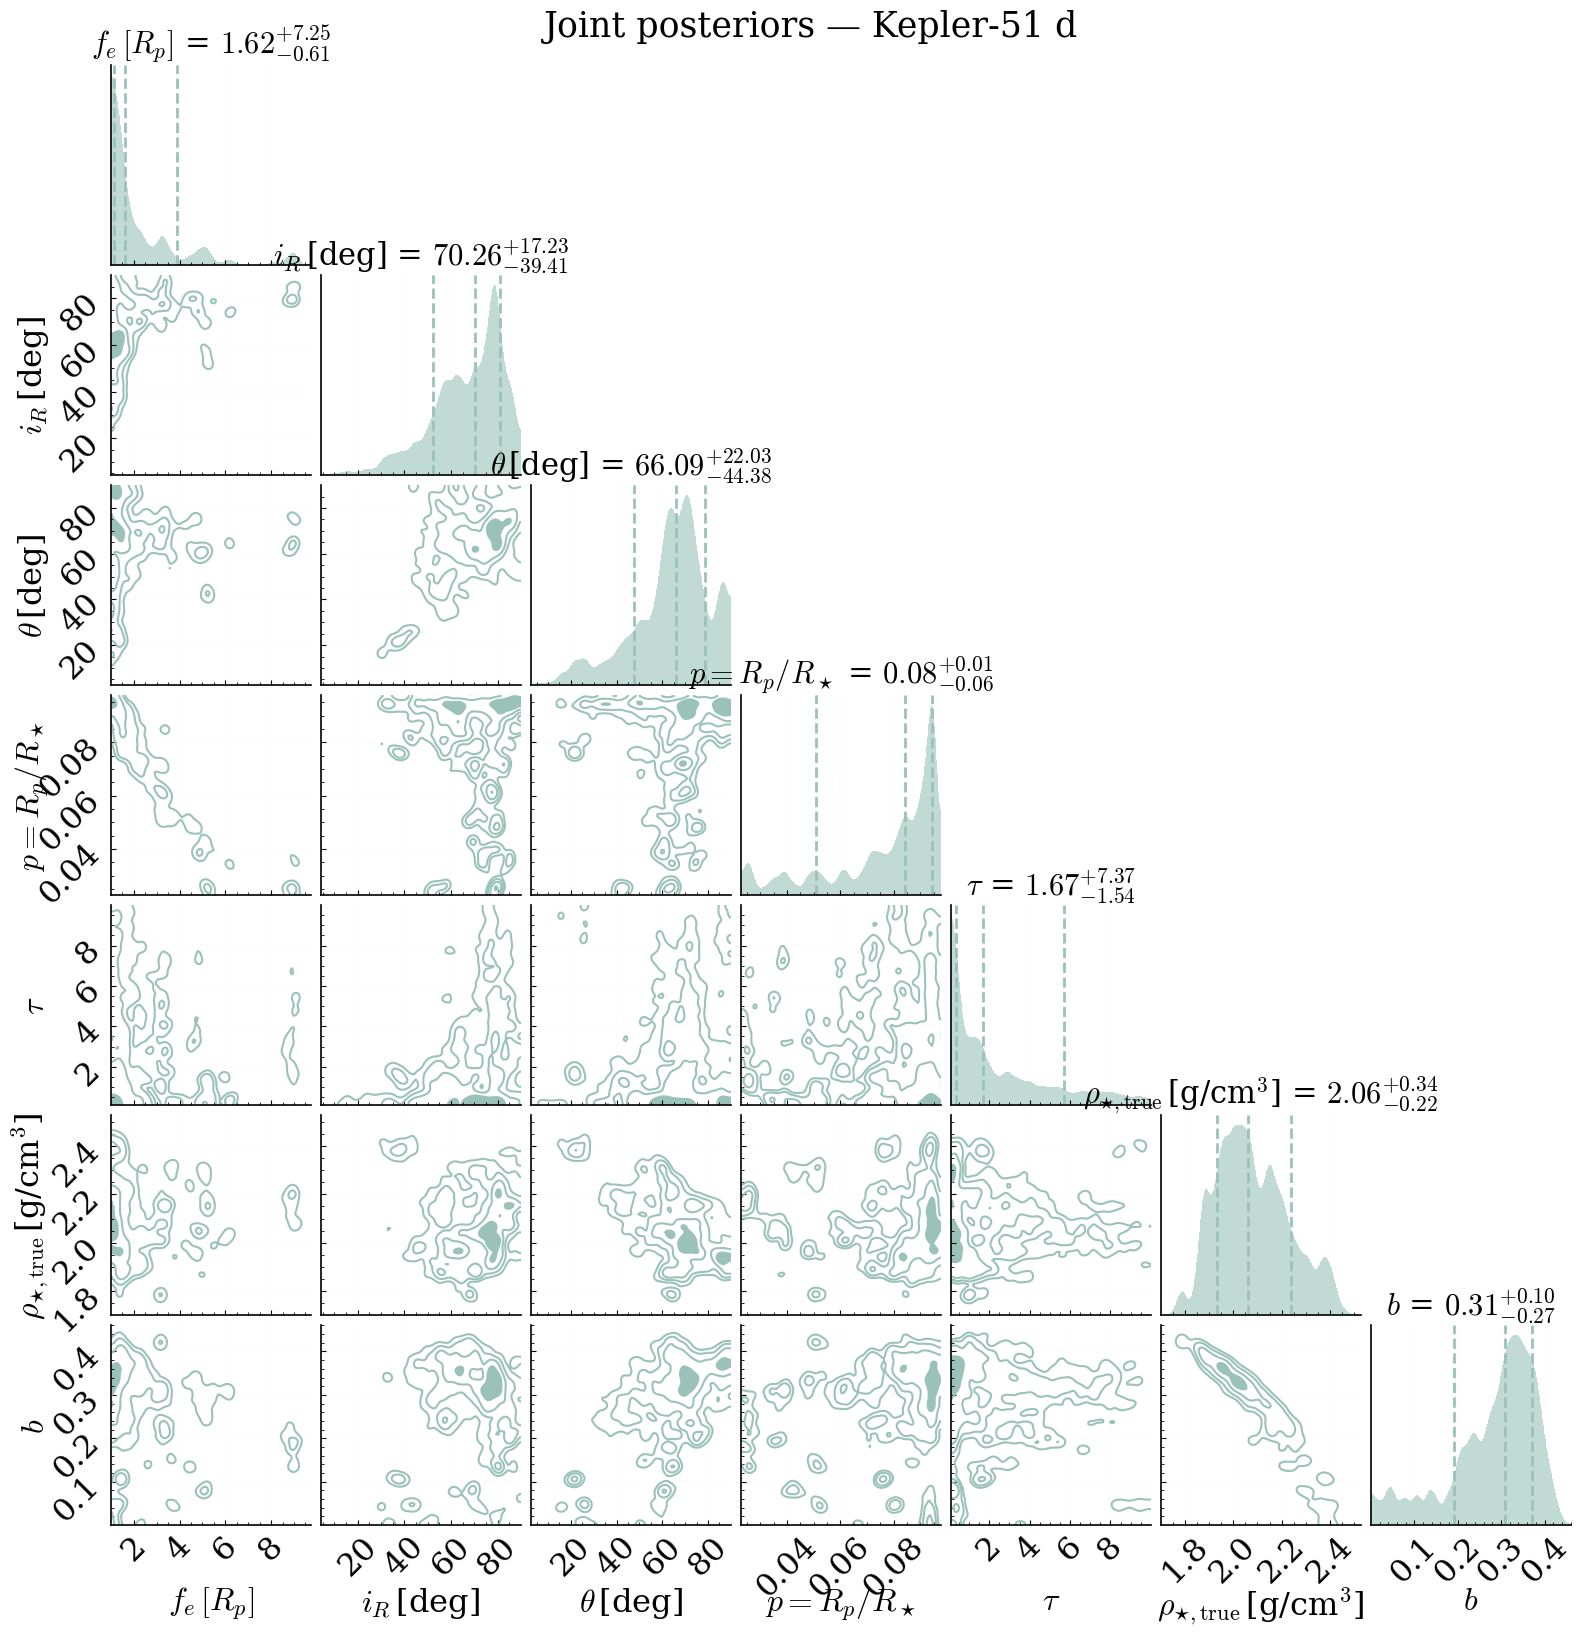

In [18]:
import matplotlib.pyplot as plt
plot.plot_marginals(run, berger_rho=data["rho_true_gcc_samples"], paths=paths); plt.show()
plot.plot_corner(run, paths=paths); plt.show()

## 9. Save results

Writes `<RUN_TAG>.npz` (chains, weighted samples, the full dynesty sampling history, and the
PPC array) plus `<RUN_TAG>_meta.json` (every configuration value and the derived summary
statistics) into `results/<forward_model>/`.

`RUN_TAG` encodes the complete configuration, so a directory of runs is self-describing and
step 3 can discover them without a manifest. Persisting the full dynesty array set (via
`photoring.io.dynesty_arrays`) is what allows a reloaded run to be replotted with the native
run/trace diagnostics, not just the corner.


In [19]:
meta = dict(
    planet=PLANET, case=CASE, run_tag=RUN_TAG, sampler="dynesty",
    kde_observables=model.observables, N_KDE=int(len(model.idx_train)),
    seed_kde=int(KDE_CONFIG["seed_kde"]),
    nlive=int(NS_CONFIG["nlive"]), sample=NS_CONFIG["sample"], dlogz=float(NS_CONFIG["dlogz"]),
    seed_ns=int(NS_CONFIG["seed"]), FORWARD_MODEL=FORWARD_MODEL,
    B_FREE=bool(model.B_FREE), B_FIXED=float(model.B_FIXED), B_SIGMA=float(model.B_SIGMA),
    RHO_TRUE_FREE=bool(model.RHO_TRUE_FREE), RHO_TRUE_FIXED=float(model.RHO_TRUE_FIXED),
    ALPHA_FREE=bool(model.ALPHA_FREE), ALPHA_FIXED=float(model.ALPHA_FIXED),
    P_FREE=bool(model.P_FREE), FI_FIXED=float(model.FI_FIXED), FE_MAX=float(model.FE_MAX),
    p_min=float(model.p_min), p_max=float(model.p_max), p_mean_ref=float(model.p_mean_ref),
    P_fixed_days=float(model.P_fixed),
    logz=float(result["logz"]), logz_err=float(result["logz_err"]),
    n_iter=int(result["n_iter"]), runtime_s=float(result["runtime_s"]),
    n_samples=int(len(result["chain"])), param_names=model.PARAM_NAMES,
)
for _n, _s in result["stats"].items():
    meta[f"stat_{_n}_median"] = float(_s["median"]); meta[f"stat_{_n}_p16"] = float(_s["p16"]); meta[f"stat_{_n}_p84"] = float(_s["p84"])

# Persist the chain, the PPC and the full dynesty sampling history, so a reloaded
# run can be replotted with the native run/trace diagnostics (not just the corner).
arrays = dict(chain=result["chain"], ppc=ppc, **pr.dynesty_arrays(dres))
pr.save_run(paths.results_dir(FORWARD_MODEL), RUN_TAG, arrays, meta)
print("Saved ->", paths.results_dir(FORWARD_MODEL))

Saved -> /home/numpaque/AppPR/pipeline/kepler_51/results/exorings
